In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add these immediately after imports, before any data loading
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('maritime_analysis_ready.csv')

df['date_id']=pd.to_datetime(df['date_id'])

df.head()

,movement_id,date_id,vessel_key,vessel_id,vessel_category_x,terminal_id,container_count,move_duration,route_geometry,date_parse_error,duration_outlier,suez_period,year_month,vessel_category_y,build_year,vessel_age,build_year_flag,terminal_name,regional_hub,fiscal_year,quarter,month,week,shift,data_quality_flag
0,637,2024-07-28,Cargo_833,833,Cargo,197,415,211.68,"{'type': 'LineString', 'coordinates': [[7.5099...",False,False,post_suez,2024-07,Container,1982,NaN,True,Tammy Strong,EMEA,2024,3,7,30,Night,Review
1,637,2024-07-28,Cargo_833,833,Cargo,197,415,211.68,"{'type': 'LineString', 'coordinates': [[7.5099...",False,False,post_suez,2024-07,Tanker,1902,NaN,True,Tammy Strong,EMEA,2024,3,7,30,Night,Review
2,637,2024-07-28,Cargo_833,833,Cargo,197,415,211.68,"{'type': 'LineString', 'coordinates': [[7.5099...",False,False,post_suez,2024-07,Cargo,2013,13.00,False,Tammy Strong,EMEA,2024,3,7,30,Night,Clean
3,266,2022-03-18,Passenger_847,84,Passenger,490,342,832.52,"{'type': 'LineString', 'coordinates': [[7.5099...",False,False,post_suez,2022-03,Passenger,2003,23.00,False,Elizabeth Norman,AMER,2022,1,3,11,Night,Clean
4,266,2022-03-18,Passenger_847,84,Passenger,490,342,832.52,"{'type': 'LineString', 'coordinates': [[7.5099...",False,False,post_suez,2022-03,Cargo,1916,NaN,True,Elizabeth Norman,AMER,2022,1,3,11,Night,Review


In [32]:
print("Dataset shape: ",df.shape)
print("Data Types: ",df.dtypes)
print("Missing Values: ",df.isnull().sum())

print("Basic Statistics (measure only): ",
      df[['move_duration','container_count','vessel_age']].describe().round(2))

print(f"Date range: {df['date_id'].min()} to {df['date_id'].max()}")

Dataset shape:  (1601, 25)
Data Types:  movement_id                   int64
date_id              datetime64[ns]
vessel_key                   object
vessel_id                     int64
vessel_category_x            object
terminal_id                   int64
container_count               int64
move_duration               float64
route_geometry               object
date_parse_error               bool
duration_outlier               bool
suez_period                  object
year_month                   object
vessel_category_y            object
build_year                    int64
vessel_age                  float64
build_year_flag                bool
terminal_name                object
regional_hub                 object
fiscal_year                   int64
quarter                       int64
month                         int64
week                          int64
shift                        object
data_quality_flag            object
dtype: object
Missing Values:  movement_id             0
dat

In [17]:
print("Basic Statistics (measure only):\n ",
      df[['move_duration','container_count','vessel_age']].describe().round(2))

print(f"Date range: {df['date_id'].min()} to {df['date_id'].max()}")

Basic Statistics (measure only):
         move_duration  container_count  vessel_age
count        1601.00          1601.00      473.00
mean          499.53           493.74       19.03
std           290.17           280.80       10.33
min             1.02             0.00        3.00
25%           243.79           253.00       10.00
50%           493.65           494.00       19.00
75%           755.47           727.00       28.00
max           998.32          1000.00       36.00
Date range: 2021-01-02 00:00:00 to 2024-12-30 00:00:00


In [18]:
print(f"Total movements: {len(df):,}")
print(f"Total container moved: {df['container_count'].sum():,}")
print(f"Avg move duration: {df['move_duration'].mean():.1f} hours")
print(f"Median move duration: {df['move_duration'].median():.1f} hours")

Total movements: 1,601
Total container moved: 790,485
Avg move duration: 499.5 hours
Median move duration: 493.7 hours


In [19]:
print(f"Suez period counts: {df['suez_period'].value_counts()}")
print(f"Shift counts: {df['shift'].value_counts()}")
print(f"Data quality flags: {df['data_quality_flag'].value_counts()}")

Suez period counts: suez_period
post_suez          1469
suez_disruption      68
pre_suez             64
Name: count, dtype: int64
Shift counts: shift
Night    808
Day      793
Name: count, dtype: int64
Data quality flags: data_quality_flag
Review    1128
Clean      473
Name: count, dtype: int64


In [20]:
vessel_analysis=df.groupby('vessel_category_x').agg(
    total_movements=('movement_id','count'),
    avg_duration_hrs=('move_duration','mean'),
    median_duration=('move_duration','median'),
    avg_containers=('container_count','mean'),
    total_containers=('container_count','sum')
).round(2)


vessel_analysis['movement_pct']=(
    vessel_analysis['total_movements']/
    vessel_analysis['total_movements'].sum()*100
).round(2)

print("---Vessel category analysis---")
print(vessel_analysis.sort_values('avg_duration_hrs',ascending=False))



---Vessel category analysis---
                   total_movements  avg_duration_hrs  median_duration  \
vessel_category_x                                                       
Cargo                          374            534.59           555.38   
Passenger                      425            499.59           485.67   
Tanker                         420            492.15           478.05   
Container                      382            473.23           442.35   

                   avg_containers  total_containers  movement_pct  
vessel_category_x                                                  
Cargo                      485.64            181631         23.36  
Passenger                  500.72            212808         26.55  
Tanker                     496.97            208727         26.23  
Container                  490.36            187319         23.86  


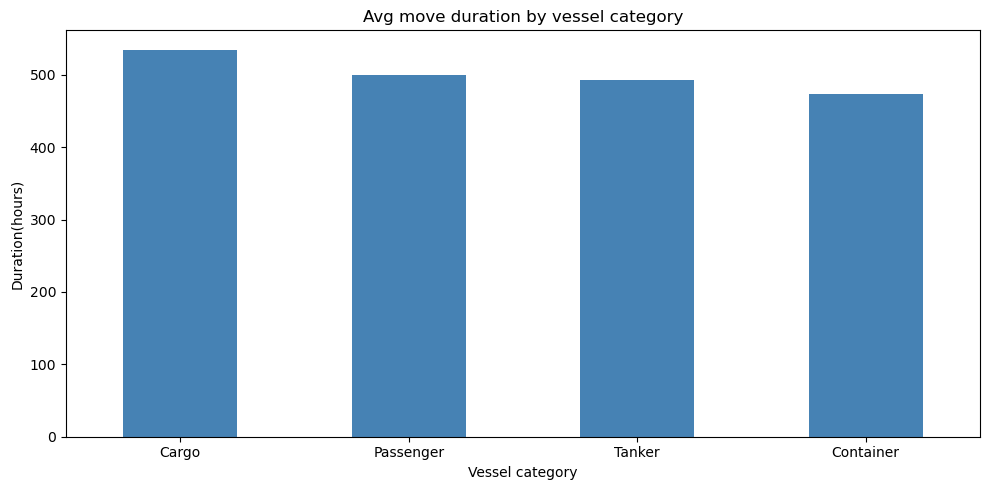

In [21]:
vessel_analysis['avg_duration_hrs'].sort_values(ascending=False).plot(
    kind='bar', figsize=(10,5),color='steelblue'
)

plt.title('Avg move duration by vessel category')
plt.ylabel('Duration(hours)')
plt.xlabel('Vessel category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---Monthy Trends---
            total_movements  avg_duration_hrs  total_containers  \
date_id                                                           
2021-01-31               37            411.93             14130   
2021-02-28               27            497.28             10999   
2021-03-31               19            547.10              9348   
2021-04-30               29            596.19             15852   
2021-05-31               20            506.19             10757   
2021-06-30               22            476.11              9445   
2021-07-31               26            430.91             13870   
2021-08-31               26            525.35             16218   
2021-09-30               29            473.44             14406   
2021-10-31               28            492.07             11214   
2021-11-30               35            540.45             19055   
2021-12-31               30            539.17             18350   
2022-01-31               26            301

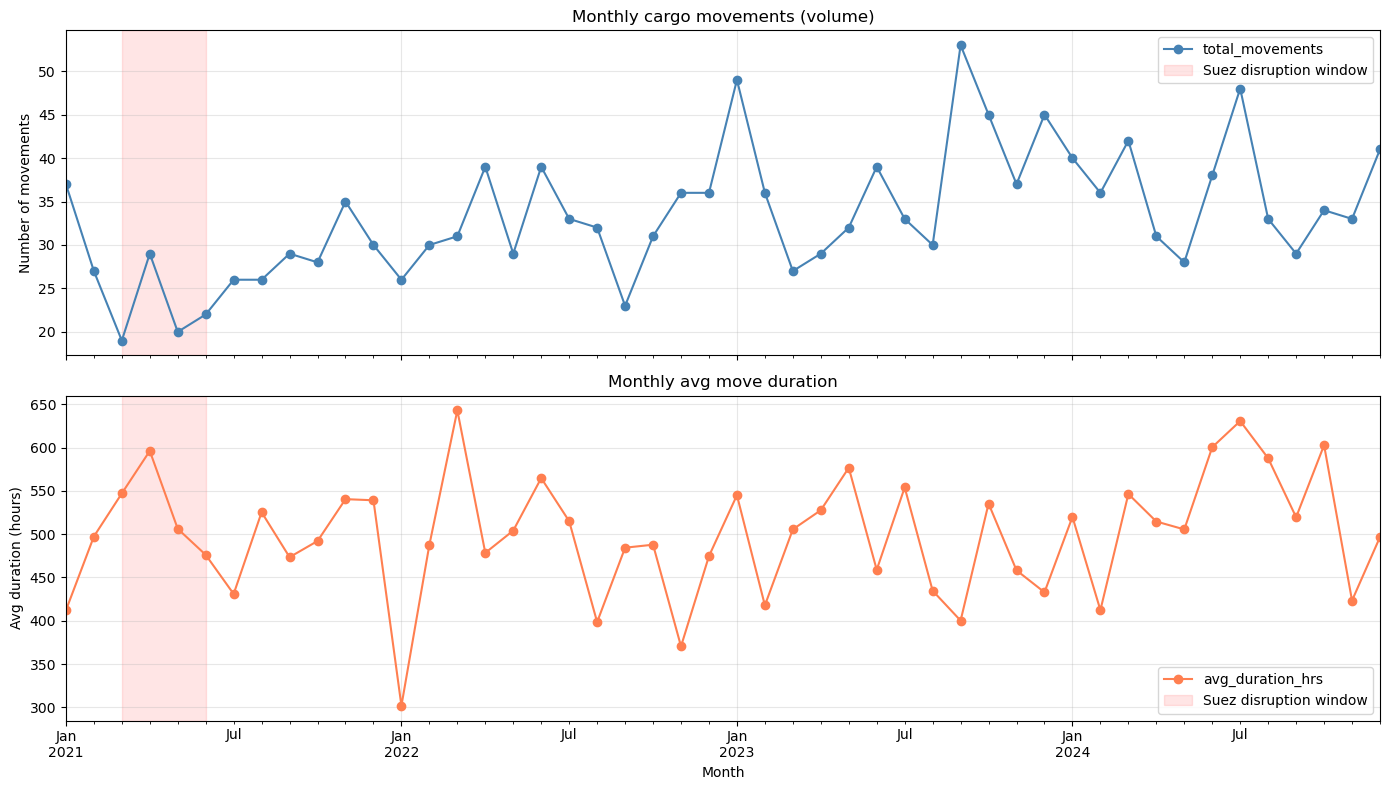

In [22]:
df_monthly=df.set_index('date_id').resample('ME').agg(
    total_movements=('movement_id','count'),
    avg_duration_hrs=('move_duration','mean'),
    total_containers=('container_count','sum'),
    avg_containers=('container_count','mean')
).round(2)

print('---Monthy Trends---')
print(df_monthly)

fig,(ax1,ax2)=plt.subplots(2,1, figsize=(14,8),sharex=True)

df_monthly['total_movements'].plot(ax=ax1,marker='o',color='steelblue')
ax1.set_title('Monthly cargo movements (volume)')
ax1.set_ylabel('Number of movements')
ax1.grid(True,alpha=0.3)
ax1.axvspan(
    pd.Timestamp('2021-03-01'),pd.Timestamp('2021-06-01'),
    color='red',alpha=0.1,label='Suez disruption window'
)
ax1.legend()

df_monthly['avg_duration_hrs'].plot(ax=ax2,marker='o',color='coral')
ax2.set_title('Monthly avg move duration')
ax2.set_ylabel('Avg duration (hours)')
ax2.set_xlabel('Month')
ax2.grid(True,alpha=0.3)
ax2.axvspan(
    pd.Timestamp('2021-03-01'),pd.Timestamp('2021-06-01'),
    color='red',alpha=0.1,label='Suez disruption window'
)
ax2.legend()

plt.tight_layout()
plt.show()

In [35]:
terminal_analysis=df.groupby(['terminal_id','terminal_name','regional_hub']).agg(
    total_movements=('movement_id','count'),
    avg_durations_hrs=('move_duration','mean'),
    total_containers=('container_count','sum'),
    avg_containers=('container_count','mean')
).round(2).reset_index()


median_load=terminal_analysis['total_movements'].median()
terminal_analysis['utilization_vs_median']=(
    terminal_analysis['total_movements']/median_load
).round(2)

def segment_terminal(row):
    if row['utilization_vs_median']>=1.7:
        return 'Overloaded'
    elif row['utilization_vs_median']>=1.3:
        return 'High Load'
    elif row['utilization_vs_median']>=0.8:
        return 'Normal'
    else:
        return 'Underutilized'
    
terminal_analysis['load_segment']=terminal_analysis.apply(segment_terminal,axis=1)

print("----Terminal Utilization analysis----")
print(terminal_analysis.sort_values('total_movements',ascending=False))
print("Load segment distribution")
print(terminal_analysis['load_segment'].value_counts())

----Terminal Utilization analysis----
    terminal_id        terminal_name regional_hub  total_movements  \
42          778         Shannon Gray         APAC               58   
41          761          David Dixon        LATAM               52   
8           197         Tammy Strong         EMEA               47   
26          529          Tara Walker         APAC               45   
18          371          Isaac Moore         EMEA               45   
9           198          Jamie Banks         APAC               43   
24          490     Elizabeth Norman         AMER               42   
11          224          Lisa Carter        LATAM               42   
29          598        Nicole Miller         EMEA               41   
28          563       Deborah Morgan        LATAM               40   
47          930         Regina White         EMEA               39   
31          627        Matthew Jones        LATAM               37   
36          728  Courtney Mclaughlin         EMEA   

----Top 15 terminals by movements volume----
          terminal_name regional_hub  total_movements  avg_durations_hrs  \
42         Shannon Gray         APAC               58             531.42   
41          David Dixon        LATAM               52             425.56   
8          Tammy Strong         EMEA               47             606.60   
26          Tara Walker         APAC               45             479.64   
18          Isaac Moore         EMEA               45             474.53   
9           Jamie Banks         APAC               43             543.70   
24     Elizabeth Norman         AMER               42             512.08   
11          Lisa Carter        LATAM               42             596.88   
29        Nicole Miller         EMEA               41             497.30   
28       Deborah Morgan        LATAM               40             506.20   
47         Regina White         EMEA               39             434.41   
31        Matthew Jones        LATAM       

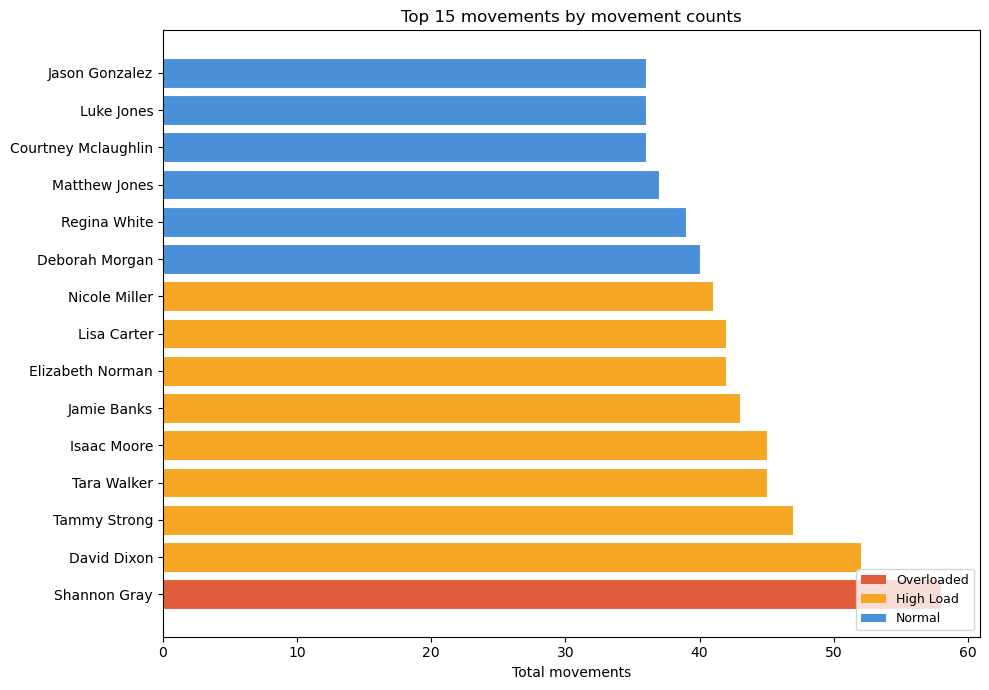

In [41]:
top_terminals=terminal_analysis.sort_values(
    'total_movements',ascending=False
).head(15)

print("----Top 15 terminals by movements volume----")
print(top_terminals[['terminal_name','regional_hub','total_movements','avg_durations_hrs','load_segment']])


colors={
    'Overloaded':    '#E05C3A',  
    'High Load':     '#F5A623',    
    'Normal':        '#4A90D9',   
    'Underutilized': '#95C8A0',
}
colors=top_terminals['load_segment'].map(colors)
plt.figure(figsize=(10,7))
plt.barh(top_terminals['terminal_name'],top_terminals['total_movements'],color=colors,edgecolor='white',linewidth=0.8)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E05C3A', label='Overloaded'),
    Patch(facecolor='#F5A623', label='High Load'),
    Patch(facecolor='#4A90D9', label='Normal'),
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.title('Top 15 movements by movement counts')
plt.xlabel('Total movements')
plt.tight_layout()
plt.show()

In [46]:
regional_analysis=df.groupby('regional_hub').agg(
    unique_terminal=('terminal_id','nunique'),
    total_movements=('movement_id','count'),
    avg_duration_hrs=('move_duration','mean'),
    total_containers=('container_count','sum'),
    avg_containers=('container_count','mean')
).round(2)

regional_analysis['movement_share_pct']=(regional_analysis['total_movements']/
regional_analysis['total_movements'].sum()*100).round(2)

print('----Regional hub analysis----')
print(regional_analysis.sort_values('total_movements',ascending=False))

----Regional hub analysis----
              unique_terminal  total_movements  avg_duration_hrs  \
regional_hub                                                       
EMEA                       19              617            495.18   
APAC                       12              404            509.20   
LATAM                       9              320            494.19   
AMER                       10              260            501.38   

              total_containers  avg_containers  movement_share_pct  
regional_hub                                                        
EMEA                    309367          501.41               38.54  
APAC                    202402          501.00               25.23  
LATAM                   145601          455.00               19.99  
AMER                    133115          511.98               16.24  


In [49]:
suez_comparison=df.groupby('suez_period').agg(
    total_movements=('movement_id','count'),
    avg_duration_hrs=('move_duration','mean'),
    total_containers=('container_count','sum'),
    avg_containers=('container_count','mean')
)

period_order=['pre_suez','suez_disruption','post_suez']
suez_comparison=suez_comparison.reindex(
    [p for p in period_order if p in suez_comparison.index]
)

pre=suez_comparison.loc['pre_suez']
dis=suez_comparison.loc['suez_disruption']

duration_impact_pct=((dis['avg_duration_hrs']-pre['avg_duration_hrs'])/pre['avg_duration_hrs']*100).round(2)

volume_impact_pct=((dis['total_movements']-pre['total_movements'])/pre['total_movements']*100).round(2)

print('----Suez period comparison')
print(suez_comparison)
print(f"Duration change during disruption vs pre suez :{duration_impact_pct:+.1f}%")
print(f"Volumne change during disruption vs pre suez :{volume_impact_pct:+.1f}%")


suez_regional=df.groupby(['suez_period','regional_hub']).agg(
    avg_duration_hrs = ('move_duration',  'mean'),
    total_movements  = ('movement_id',    'count')
).round(2).reset_index()

print("---Suez impact by regional hub----")
print(suez_regional.sort_values(['suez_period','avg_duration_hrs'],ascending=[True,False]))

----Suez period comparison
                 total_movements  avg_duration_hrs  total_containers  \
suez_period                                                            
pre_suez                      64            447.94             25129   
suez_disruption               68            556.00             35957   
post_suez                   1469            499.16            729399   

                 avg_containers  
suez_period                      
pre_suez                 392.64  
suez_disruption          528.78  
post_suez                496.53  
Duration change during disruption vs pre suez :+24.1%
Volumne change during disruption vs pre suez :+6.2%
---Suez impact by regional hub----
        suez_period regional_hub  avg_duration_hrs  total_movements
1         post_suez         APAC            509.06              383
2         post_suez         EMEA            499.47              564
3         post_suez        LATAM            494.79              283
0         post_suez         A